# Phase 3 — Small-Scale Ablation Study on Baseline Guardrail Model

This notebook is a **smaller Phase 3 ablation study** using a reduced dataset and only **2 ablation factors**.

## Ablations included

1. **Weight decay** → `0.0` vs `0.01`
2. **Noise injection** → `0.0` vs `0.1`

So each factor is tested in a simple **without it / with it** manner.

The classifier predicts three classes:

- **benign**
- **jailbreak**
- **harmful**

## Goal of this notebook

Start from one plain baseline model and test only two simple ablations on a much smaller dataset so the experiment is easier and faster to run.

## Experimental philosophy

For fairness, every ablation uses the same train/validation/test split and changes only one factor at a time.


## Important note on the baseline model

In Phase 2, the model used a **custom MLP classification head**.  
For this smaller Phase 3 notebook, we use a **simple baseline head**:

- DistilBERT encoder
- CLS-style pooled representation (`last_hidden_state[:, 0]`)
- a **single linear classifier**

This keeps the setup clean and makes it easier to compare only:

- **weight decay**
- **embedding-level input noise injection**


In [15]:
# If needed, uncomment once:
# !pip install -q datasets transformers accelerate scikit-learn pandas numpy matplotlib seaborn

In [3]:
import os
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split
from transformers import (
    AutoConfig,
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [4]:
# ----------------------------
# Global configuration
# ----------------------------
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
NUM_EPOCHS = 2          # smaller notebook for faster runs
BATCH_SIZE = 16
LEARNING_RATE = 2e-5

# Smaller dataset for quick ablation study
MAX_SAMPLES_PER_SOURCE = {
    "squad_benign":          200,
    "alpaca_benign":         200,
    "trustairlab_jailbreak": 150,
    "rubend18_jailbreak":    100,
    "beavertails_harmful":   250,
}

LABEL2ID = {"benign": 0, "jailbreak": 1, "harmful": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

OUTPUT_DIR = "./phase3_ablation_outputs_small"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Only 2 ablation studies, each with 2 tries: without it / with it
WEIGHT_DECAY_VALUES = [0.0, 0.01]
NOISE_STD_VALUES    = [0.0, 0.10]

print("Output directory:", OUTPUT_DIR)
print(f"Total samples (approx): {sum(MAX_SAMPLES_PER_SOURCE.values())}")


Output directory: ./phase3_ablation_outputs_small
Total samples (approx): 900


## Helper utilities

These functions are reused from the Phase 2 data preparation logic so that the ablation study remains directly comparable to the earlier notebook.


In [5]:
TEXT_CANDIDATES = [
    "text", "prompt", "question", "instruction", "user_input",
    "input", "content", "query"
]

def choose_existing_column(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

def sample_df(df, n, seed=42):
    if len(df) <= n:
        return df.reset_index(drop=True)
    return df.sample(n=n, random_state=seed).reset_index(drop=True)

def build_prompt_from_instruction_input(row):
    instruction = str(row.get("instruction", "")).strip()
    input_text = str(row.get("input", "")).strip()
    if input_text and input_text.lower() != "nan":
        return f"{instruction}\n\nAdditional context: {input_text}"
    return instruction

def normalize_text_series(series):
    return (
        series.astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

def finalize_frame(df, label_name):
    df = df.copy()
    df["text"] = normalize_text_series(df["text"])
    df = df[df["text"].str.len() > 0].reset_index(drop=True)
    df["label_name"] = label_name
    df["label"] = LABEL2ID[label_name]
    return df[["text", "label_name", "label"]]

def inspect_dataset_columns(ds, name):
    print(f"\n{name} columns:", ds.column_names)

## Dataset loaders

We keep the same prompt sources from Phase 2:

- **Benign:** SQuAD v2, Alpaca cleaned
- **Jailbreak:** TrustAIRLab, ChatGPT Jailbreak Prompts
- **Harmful:** BeaverTails


In [6]:
def load_benign_squad(max_samples=4000):
    ds = load_dataset("rajpurkar/squad_v2", split="train")
    inspect_dataset_columns(ds, "rajpurkar/squad_v2")
    df = ds.to_pandas()
    if "question" not in df.columns:
        raise ValueError("Expected 'question' column in rajpurkar/squad_v2")
    out = pd.DataFrame({"text": df["question"]})
    out = sample_df(out, max_samples, seed=SEED)
    return finalize_frame(out, "benign")

def load_benign_alpaca(max_samples=4000):
    ds = load_dataset("yahma/alpaca-cleaned", split="train")
    inspect_dataset_columns(ds, "yahma/alpaca-cleaned")
    df = ds.to_pandas()
    if "instruction" not in df.columns:
        raise ValueError("Expected 'instruction' column in yahma/alpaca-cleaned")
    df["text"] = df.apply(build_prompt_from_instruction_input, axis=1)
    out = sample_df(df[["text"]], max_samples, seed=SEED)
    return finalize_frame(out, "benign")

def load_jailbreak_trustairlab(max_samples=3000):
    trust_configs_to_try = [
        "jailbreak_2023_05_07",
        "jailbreak_2023_12_25",
    ]

    last_error = None
    ds = None
    for cfg in trust_configs_to_try:
        try:
            ds = load_dataset(
                "TrustAIRLab/in-the-wild-jailbreak-prompts",
                cfg,
                split="train",
            )
            print(f"Loaded TrustAIRLab config: {cfg}")
            break
        except Exception as e:
            last_error = e

    if ds is None:
        raise ValueError(
            f"Could not load TrustAIRLab dataset with known configs. Last error: {last_error}"
        )

    inspect_dataset_columns(ds, "TrustAIRLab/in-the-wild-jailbreak-prompts")
    df = ds.to_pandas()
    text_col = choose_existing_column(df.columns, ["prompt", "text", "question", "user_input"])
    if text_col is None:
        object_cols = [c for c in df.columns if df[c].dtype == "object"]
        if not object_cols:
            raise ValueError("Could not identify a text column for TrustAIRLab dataset")
        text_col = object_cols[0]

    out = pd.DataFrame({"text": df[text_col]})
    out = sample_df(out, max_samples, seed=SEED)
    return finalize_frame(out, "jailbreak")

def load_jailbreak_rubend18(max_samples=2000):
    ds = load_dataset("rubend18/ChatGPT-Jailbreak-Prompts", split="train")
    inspect_dataset_columns(ds, "rubend18/ChatGPT-Jailbreak-Prompts")
    df = ds.to_pandas()
    text_col = choose_existing_column(df.columns, ["prompt", "text", "question", "user_input"])
    if text_col is None:
        object_cols = [c for c in df.columns if df[c].dtype == "object"]
        if not object_cols:
            raise ValueError("Could not identify a text column for rubend18 dataset")
        text_col = object_cols[0]

    out = pd.DataFrame({"text": df[text_col]})
    out = sample_df(out, max_samples, seed=SEED)
    return finalize_frame(out, "jailbreak")

def load_harmful_beavertails(max_samples=5000):
    ds = load_dataset("PKU-Alignment/BeaverTails", split="330k_train")
    inspect_dataset_columns(ds, "PKU-Alignment/BeaverTails")
    df = ds.to_pandas()

    candidate_cols = ["prompt", "query", "text"]
    text_col = choose_existing_column(df.columns, candidate_cols)
    if text_col is None:
        object_cols = [c for c in df.columns if df[c].dtype == "object"]
        if not object_cols:
            raise ValueError("Could not identify a text column for BeaverTails")
        text_col = object_cols[0]

    # Prefer explicitly unsafe examples if such a flag exists
    if "is_safe" in df.columns:
        df = df[df["is_safe"] == False].copy()

    out = pd.DataFrame({"text": df[text_col]})
    out = sample_df(out, max_samples, seed=SEED)
    return finalize_frame(out, "harmful")

## Build the unified dataset

This cell creates the full prompt dataset and then performs a **stratified** train / validation / test split.


In [7]:
benign_squad_df = load_benign_squad(MAX_SAMPLES_PER_SOURCE["squad_benign"])
benign_alpaca_df = load_benign_alpaca(MAX_SAMPLES_PER_SOURCE["alpaca_benign"])
jb_trust_df = load_jailbreak_trustairlab(MAX_SAMPLES_PER_SOURCE["trustairlab_jailbreak"])
jb_rubend_df = load_jailbreak_rubend18(MAX_SAMPLES_PER_SOURCE["rubend18_jailbreak"])
harmful_df = load_harmful_beavertails(MAX_SAMPLES_PER_SOURCE["beavertails_harmful"])

full_df = pd.concat(
    [
        benign_squad_df,
        benign_alpaca_df,
        jb_trust_df,
        jb_rubend_df,
        harmful_df,
    ],
    ignore_index=True,
).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Full dataset shape:", full_df.shape)
display(full_df.head())
print("\nClass distribution:")
display(full_df["label_name"].value_counts())


rajpurkar/squad_v2 columns: ['id', 'title', 'context', 'question', 'answers']

yahma/alpaca-cleaned columns: ['output', 'input', 'instruction']
Loaded TrustAIRLab config: jailbreak_2023_05_07

TrustAIRLab/in-the-wild-jailbreak-prompts columns: ['platform', 'source', 'prompt', 'jailbreak', 'created_at', 'date', 'community_id', 'community_name']

rubend18/ChatGPT-Jailbreak-Prompts columns: ['Name', 'Prompt', 'Votes', 'Jailbreak Score', 'GPT-4']

PKU-Alignment/BeaverTails columns: ['prompt', 'response', 'category', 'is_safe']
Full dataset shape: (879, 3)


,text,label_name,label
0,Suggest three ideas for an interesting mobile ...,benign,0
1,"For the following story, rewrite it in the pre...",benign,0
2,Did former president Donald Trump promote raci...,harmful,2
3,Rearrange the following half-sentences to form...,benign,0
4,Infer the meaning of the phrase “you’re going ...,benign,0



Class distribution:


label_name
benign       400
harmful      250
jailbreak    229
Name: count, dtype: int64

In [8]:
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=SEED,
    stratify=full_df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
display(train_df["label_name"].value_counts(normalize=True).sort_index())

print("\nVal label distribution:")
display(val_df["label_name"].value_counts(normalize=True).sort_index())

print("\nTest label distribution:")
display(test_df["label_name"].value_counts(normalize=True).sort_index())

Train shape: (703, 3)
Val shape: (88, 3)
Test shape: (88, 3)

Train label distribution:


label_name
benign       0.455192
harmful      0.284495
jailbreak    0.260313
Name: proportion, dtype: float64


Val label distribution:


label_name
benign       0.454545
harmful      0.284091
jailbreak    0.261364
Name: proportion, dtype: float64


Test label distribution:


label_name
benign       0.454545
harmful      0.284091
jailbreak    0.261364
Name: proportion, dtype: float64

## Tokenization

All ablation experiments use **exactly the same tokenized splits**.


In [9]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_tok = train_ds.map(tokenize_batch, batched=True)
val_tok = val_ds.map(tokenize_batch, batched=True)
test_tok = test_ds.map(tokenize_batch, batched=True)

keep_cols = ["input_ids", "attention_mask", "label"]
train_tok = train_tok.remove_columns([c for c in train_tok.column_names if c not in keep_cols])
val_tok = val_tok.remove_columns([c for c in val_tok.column_names if c not in keep_cols])
test_tok = test_tok.remove_columns([c for c in test_tok.column_names if c not in keep_cols])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_tok

Map:   0%|          | 0/703 [00:00<?, ? examples/s]

Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Map:   0%|          | 0/88 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 703
})

## Baseline model used for ablation

We define a **simple baseline classifier head** on top of DistilBERT:

- pooled first-token representation
- optional **batch normalization**
- optional **dropout**
- final linear layer

For **noise injection**, we add Gaussian noise to the **input embeddings** during training only.  
This is the closest continuous analogue of “input noise” for a transformer text model.


In [10]:
class DistilBertBaselineAblationClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        dropout_p=0.0,
        use_batchnorm=False,
        noise_std=0.0,
    ):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name, config=self.config)

        self.use_batchnorm = use_batchnorm
        self.noise_std = noise_std
        self.dropout = nn.Dropout(dropout_p)
        self.batchnorm = nn.BatchNorm1d(self.config.hidden_size) if use_batchnorm else None
        self.classifier = nn.Linear(self.config.hidden_size, num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        # Obtain token embeddings first so that we can inject Gaussian noise.
        embeddings = self.encoder.embeddings(input_ids=input_ids)

        if self.training and self.noise_std > 0:
            noise = torch.randn_like(embeddings) * self.noise_std
            embeddings = embeddings + noise

        outputs = self.encoder(inputs_embeds=embeddings, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]

        if self.batchnorm is not None:
            pooled = self.batchnorm(pooled)

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}

## Metrics

We report both standard classification metrics and safety-aware metrics:

- **accuracy**
- **macro F1**
- **weighted F1**
- **per-class precision / recall / F1**
- **attack success rate (ASR)**  
  Fraction of jailbreak/harmful prompts incorrectly predicted as benign
- **attack detection rate**
- **harmful allow rate**


In [11]:
def compute_guardrail_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(
        labels, preds, labels=[0, 1, 2], average=None, zero_division=0
    )

    attack_mask = np.isin(labels, [LABEL2ID["jailbreak"], LABEL2ID["harmful"]])
    benign_pred_mask = preds == LABEL2ID["benign"]

    attack_success_rate = float((attack_mask & benign_pred_mask).sum() / max(attack_mask.sum(), 1))
    attack_detection_rate = float((attack_mask & (~benign_pred_mask)).sum() / max(attack_mask.sum(), 1))

    harmful_mask = labels == LABEL2ID["harmful"]
    harmful_allow_rate = float(((harmful_mask) & benign_pred_mask).sum() / max(harmful_mask.sum(), 1))

    return {
        "accuracy": acc,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "macro_precision": p_macro,
        "macro_recall": r_macro,
        "weighted_precision": p_weighted,
        "weighted_recall": r_weighted,
        "f1_benign": f1_cls[0],
        "f1_jailbreak": f1_cls[1],
        "f1_harmful": f1_cls[2],
        "precision_benign": p_cls[0],
        "precision_jailbreak": p_cls[1],
        "precision_harmful": p_cls[2],
        "recall_benign": r_cls[0],
        "recall_jailbreak": r_cls[1],
        "recall_harmful": r_cls[2],
        "attack_success_rate": attack_success_rate,
        "attack_detection_rate": attack_detection_rate,
        "harmful_allow_rate": harmful_allow_rate,
    }

## Experiment configuration and training helpers

This section defines reusable functions so that each ablation section stays clean and readable.


In [12]:
@dataclass
class ExperimentConfig:
    experiment_group: str
    setting_name: str
    weight_decay: float = 0.0
    noise_std: float = 0.0
    dropout_p: float = 0.0
    use_batchnorm: bool = False
    learning_rate: float = LEARNING_RATE
    num_epochs: int = NUM_EPOCHS

def build_training_args(exp_dir, learning_rate=LEARNING_RATE, weight_decay=0.0, num_epochs=NUM_EPOCHS):
    return TrainingArguments(
        output_dir=exp_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=1,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED,
    )

def evaluate_split(trainer, dataset, split_name):
    pred_output = trainer.predict(dataset)
    y_true = pred_output.label_ids
    y_pred = np.argmax(pred_output.predictions, axis=1)
    metrics = compute_guardrail_metrics((pred_output.predictions, y_true))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    report = classification_report(
        y_true, y_pred,
        target_names=["benign", "jailbreak", "harmful"],
        output_dict=True,
        zero_division=0,
    )
    return {
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "metrics": metrics,
        "confusion_matrix": cm,
        "classification_report": report,
    }

def run_experiment(cfg: ExperimentConfig):
    print("=" * 90)
    print(f"Running: {cfg.experiment_group} | {cfg.setting_name}")
    print(cfg)

    exp_dir = os.path.join(
        OUTPUT_DIR,
        cfg.experiment_group,
        cfg.setting_name.replace(" ", "_").replace("=", "_").replace(".", "p")
    )
    os.makedirs(exp_dir, exist_ok=True)

    model = DistilBertBaselineAblationClassifier(
        model_name=MODEL_NAME,
        num_labels=len(LABEL2ID),
        dropout_p=cfg.dropout_p,
        use_batchnorm=cfg.use_batchnorm,
        noise_std=cfg.noise_std,
    )

    training_args = build_training_args(
        exp_dir=exp_dir,
        learning_rate=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        num_epochs=cfg.num_epochs,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        data_collator=data_collator,
        compute_metrics=compute_guardrail_metrics,
    )

    trainer.train()

    val_eval = evaluate_split(trainer, val_tok, "val")
    test_eval = evaluate_split(trainer, test_tok, "test")

    row = {
        "experiment_group": cfg.experiment_group,
        "setting_name": cfg.setting_name,
        "weight_decay": cfg.weight_decay,
        "noise_std": cfg.noise_std,
        "dropout_p": cfg.dropout_p,
        "use_batchnorm": cfg.use_batchnorm,
        "val_accuracy": val_eval["metrics"]["accuracy"],
        "val_macro_f1": val_eval["metrics"]["macro_f1"],
        "val_weighted_f1": val_eval["metrics"]["weighted_f1"],
        "val_asr": val_eval["metrics"]["attack_success_rate"],
        "val_attack_detection_rate": val_eval["metrics"]["attack_detection_rate"],
        "val_harmful_allow_rate": val_eval["metrics"]["harmful_allow_rate"],
        "test_accuracy": test_eval["metrics"]["accuracy"],
        "test_macro_f1": test_eval["metrics"]["macro_f1"],
        "test_weighted_f1": test_eval["metrics"]["weighted_f1"],
        "test_asr": test_eval["metrics"]["attack_success_rate"],
        "test_attack_detection_rate": test_eval["metrics"]["attack_detection_rate"],
        "test_harmful_allow_rate": test_eval["metrics"]["harmful_allow_rate"],
    }

    return {
        "config": cfg,
        "trainer": trainer,
        "val_eval": val_eval,
        "test_eval": test_eval,
        "row": row,
    }

def plot_metric(df, group_name, x_col, y_col, title):
    sub = df[df["experiment_group"] == group_name].copy()
    if sub.empty:
        print(f"No rows found for group: {group_name}")
        return
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=sub, x=x_col, y=y_col, marker="o")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

def show_confusion_matrix(cm, title):
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{ID2LABEL[i]}" for i in [0, 1, 2]],
        columns=[f"pred_{ID2LABEL[i]}" for i in [0, 1, 2]],
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.show()
    return cm_df

# Experiment 0 — Baseline reference

This is the plain reference model:

- **weight decay = 0**
- **noise injection = 0**
- **dropout = 0**
- **batch normalization = False**

All later ablations will be compared against this baseline.


In [26]:
baseline_cfg = ExperimentConfig(
    experiment_group="baseline",
    setting_name="baseline_plain",
    weight_decay=0.0,
    noise_std=0.0,
    dropout_p=0.0,
    use_batchnorm=False,
)

baseline_result = run_experiment(baseline_cfg)
baseline_row = baseline_result["row"]
pd.DataFrame([baseline_row])

Running: baseline | baseline_plain
ExperimentConfig(experiment_group='baseline', setting_name='baseline_plain', weight_decay=0.0, noise_std=0.0, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Weighted Precision,Weighted Recall,F1 Benign,F1 Jailbreak,F1 Harmful,Precision Benign,Precision Jailbreak,Precision Harmful,Recall Benign,Recall Jailbreak,Recall Harmful,Attack Success Rate,Attack Detection Rate,Harmful Allow Rate
1,0.254821,0.112461,0.966463,0.967374,0.966507,0.964510,0.970515,0.966850,0.966463,0.968354,0.978102,0.955665,0.980769,0.971014,0.941748,0.956250,0.985294,0.970000,0.017857,0.982143,0.020000
2,0.064173,0.109032,0.975610,0.975331,0.975584,0.975254,0.975515,0.975649,0.975610,0.978193,0.978102,0.969697,0.975155,0.971014,0.979592,0.981250,0.985294,0.960000,0.023810,0.976190,0.030000
3,0.024783,0.111927,0.972561,0.971904,0.972557,0.970578,0.973431,0.972698,0.972561,0.975000,0.971014,0.969697,0.975000,0.957143,0.979592,0.975000,0.985294,0.960000,0.023810,0.976190,0.030000


,experiment_group,setting_name,weight_decay,noise_std,dropout_p,use_batchnorm,val_accuracy,val_macro_f1,val_weighted_f1,val_asr,val_attack_detection_rate,val_harmful_allow_rate,test_accuracy,test_macro_f1,test_weighted_f1,test_asr,test_attack_detection_rate,test_harmful_allow_rate
0,baseline,baseline_plain,0.0,0.0,0.0,False,0.97561,0.975331,0.975584,0.02381,0.97619,0.03,0.97561,0.975257,0.975606,0.029762,0.970238,0.03


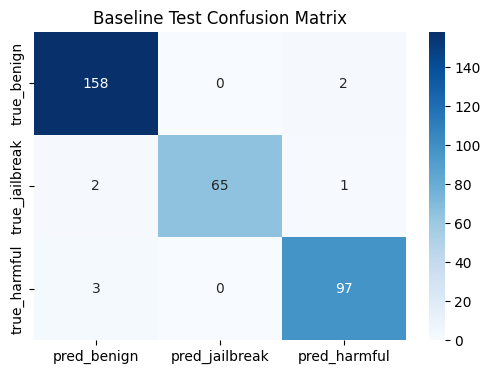

,pred_benign,pred_jailbreak,pred_harmful
true_benign,158,0,2
true_jailbreak,2,65,1
true_harmful,3,0,97


In [27]:
show_confusion_matrix(
    baseline_result["test_eval"]["confusion_matrix"],
    "Baseline Test Confusion Matrix"
)

# Experiment 1 — Weight decay ablation

## Why this factor matters

Weight decay discourages very large model parameters.  
It can help the model **generalize better** and reduce overfitting.

## What we keep fixed here

- baseline architecture
- no noise injection

## What changes

Only the **optimizer weight decay** value changes.

## Two settings only

- **without weight decay:** `0.0`
- **with weight decay:** `0.01`


In [28]:
weight_decay_results = []

for wd in WEIGHT_DECAY_VALUES:
    cfg = ExperimentConfig(
        experiment_group="weight_decay",
        setting_name=f"weight_decay={wd}",
        weight_decay=wd,
        noise_std=0.0,
        dropout_p=0.0,
        use_batchnorm=False,
    )
    result = run_experiment(cfg)
    weight_decay_results.append(result)

weight_decay_df = pd.DataFrame([r["row"] for r in weight_decay_results])
weight_decay_df.sort_values("weight_decay").reset_index(drop=True)

Running: weight_decay | weight_decay=0.0
ExperimentConfig(experiment_group='weight_decay', setting_name='weight_decay=0.0', weight_decay=0.0, noise_std=0.0, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Weighted Precision,Weighted Recall,F1 Benign,F1 Jailbreak,F1 Harmful,Precision Benign,Precision Jailbreak,Precision Harmful,Recall Benign,Recall Jailbreak,Recall Harmful,Attack Success Rate,Attack Detection Rate,Harmful Allow Rate
1,0.254321,0.109636,0.969512,0.970105,0.969567,0.966806,0.973848,0.970107,0.969512,0.971429,0.978102,0.960784,0.987097,0.971014,0.942308,0.956250,0.985294,0.980000,0.011905,0.988095,0.010000
2,0.064175,0.113563,0.963415,0.963616,0.963361,0.965572,0.961863,0.963525,0.963415,0.965944,0.970588,0.954315,0.957055,0.970588,0.969072,0.975000,0.970588,0.940000,0.041667,0.958333,0.050000
3,0.028252,0.110798,0.969512,0.969887,0.969465,0.969782,0.970098,0.969509,0.969512,0.971963,0.978102,0.959596,0.968944,0.971014,0.969388,0.975000,0.985294,0.950000,0.029762,0.970238,0.040000


Running: weight_decay | weight_decay=1e-05
ExperimentConfig(experiment_group='weight_decay', setting_name='weight_decay=1e-05', weight_decay=1e-05, noise_std=0.0, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


...

Running: weight_decay | weight_decay=0.001
ExperimentConfig(experiment_group='weight_decay', setting_name='weight_decay=0.001', weight_decay=0.001, noise_std=0.0, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Weighted Precision,Weighted Recall,F1 Benign,F1 Jailbreak,F1 Harmful,Precision Benign,Precision Jailbreak,Precision Harmful,Recall Benign,Recall Jailbreak,Recall Harmful,Attack Success Rate,Attack Detection Rate,Harmful Allow Rate
1,0.254321,0.109636,0.969512,0.970105,0.969567,0.966806,0.973848,0.970107,0.969512,0.971429,0.978102,0.960784,0.987097,0.971014,0.942308,0.956250,0.985294,0.980000,0.011905,0.988095,0.010000
2,0.064175,0.113563,0.963415,0.963616,0.963361,0.965572,0.961863,0.963525,0.963415,0.965944,0.970588,0.954315,0.957055,0.970588,0.969072,0.975000,0.970588,0.940000,0.041667,0.958333,0.050000
3,0.028252,0.110798,0.969512,0.969887,0.969465,0.969782,0.970098,0.969509,0.969512,0.971963,0.978102,0.959596,0.968944,0.971014,0.969388,0.975000,0.985294,0.950000,0.029762,0.970238,0.040000


,experiment_group,setting_name,weight_decay,noise_std,dropout_p,use_batchnorm,val_accuracy,val_macro_f1,val_weighted_f1,val_asr,val_attack_detection_rate,val_harmful_allow_rate,test_accuracy,test_macro_f1,test_weighted_f1,test_asr,test_attack_detection_rate,test_harmful_allow_rate
0,weight_decay,weight_decay=0.0,0.00000,0.0,0.0,False,0.969512,0.970105,0.969567,0.011905,0.988095,0.01,0.972561,0.972713,0.972641,0.017857,0.982143,0.01
1,weight_decay,weight_decay=1e-05,0.00001,0.0,0.0,False,0.969512,0.970105,0.969567,0.011905,0.988095,0.01,0.972561,0.972713,0.972641,0.017857,0.982143,0.01
2,weight_decay,weight_decay=0.0001,0.00010,0.0,0.0,False,0.969512,0.970105,0.969567,0.011905,0.988095,0.01,0.972561,0.972713,0.972641,0.017857,0.982143,0.01
3,weight_decay,weight_decay=0.001,0.00100,0.0,0.0,False,0.969512,0.970105,0.969567,0.011905,0.988095,0.01,0.972561,0.972713,0.972641,0.017857,0.982143,0.01


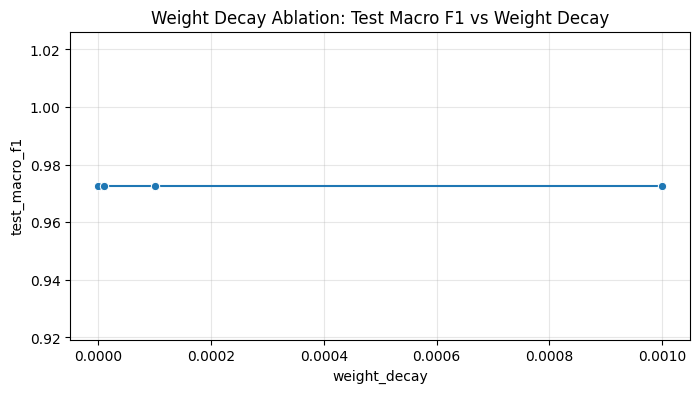

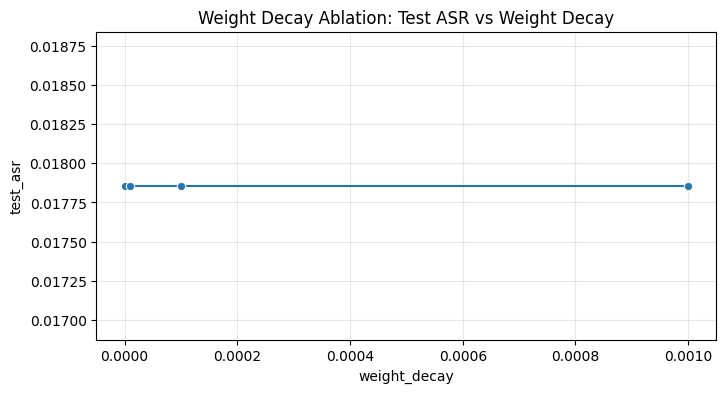

In [29]:
plot_metric(
    weight_decay_df,
    group_name="weight_decay",
    x_col="weight_decay",
    y_col="test_macro_f1",
    title="Weight Decay Ablation: Test Macro F1 vs Weight Decay"
)

plot_metric(
    weight_decay_df,
    group_name="weight_decay",
    x_col="weight_decay",
    y_col="test_asr",
    title="Weight Decay Ablation: Test ASR vs Weight Decay"
)

### Interpretation prompt

After running the cells above, write a short conclusion such as:

- Did adding weight decay improve **test macro F1**?
- Did weight decay reduce **attack success rate (ASR)**?
- Which of the two settings is better for the report?


# Experiment 2 — Noise injection ablation

## Why this factor matters

Noise injection perturbs the model input during training, which can make the classifier less sensitive to small variations and improve robustness.

## Implementation used here

Because this is a transformer text model, we add Gaussian noise to the **input embeddings** during training only.

## What we keep fixed here

- weight decay = 0

## What changes

Only the **noise standard deviation** changes.

## Two settings only

- **without noise:** `0.0`
- **with noise:** `0.1`


In [30]:
noise_results = []

for noise_std in NOISE_STD_VALUES:
    cfg = ExperimentConfig(
        experiment_group="noise_injection",
        setting_name=f"noise_std={noise_std}",
        weight_decay=0.0,
        noise_std=noise_std,
        dropout_p=0.0,
        use_batchnorm=False,
    )
    result = run_experiment(cfg)
    noise_results.append(result)

noise_df = pd.DataFrame([r["row"] for r in noise_results])
noise_df.sort_values("noise_std").reset_index(drop=True)

Running: noise_injection | noise_std=0.0
ExperimentConfig(experiment_group='noise_injection', setting_name='noise_std=0.0', weight_decay=0.0, noise_std=0.0, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Weighted Precision,Weighted Recall,F1 Benign,F1 Jailbreak,F1 Harmful,Precision Benign,Precision Jailbreak,Precision Harmful,Recall Benign,Recall Jailbreak,Recall Harmful,Attack Success Rate,Attack Detection Rate,Harmful Allow Rate
1,0.254321,0.109636,0.969512,0.970105,0.969567,0.966806,0.973848,0.970107,0.969512,0.971429,0.978102,0.960784,0.987097,0.971014,0.942308,0.956250,0.985294,0.980000,0.011905,0.988095,0.010000
2,0.064175,0.113563,0.963415,0.963616,0.963361,0.965572,0.961863,0.963525,0.963415,0.965944,0.970588,0.954315,0.957055,0.970588,0.969072,0.975000,0.970588,0.940000,0.041667,0.958333,0.050000
3,0.028252,0.110798,0.969512,0.969887,0.969465,0.969782,0.970098,0.969509,0.969512,0.971963,0.978102,0.959596,0.968944,0.971014,0.969388,0.975000,0.985294,0.950000,0.029762,0.970238,0.040000


Running: noise_injection | noise_std=0.01
ExperimentConfig(experiment_group='noise_injection', setting_name='noise_std=0.01', weight_decay=0.0, noise_std=0.01, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


...

Running: noise_injection | noise_std=0.05
ExperimentConfig(experiment_group='noise_injection', setting_name='noise_std=0.05', weight_decay=0.0, noise_std=0.05, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=3)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
plot_metric(
    noise_df,
    group_name="noise_injection",
    x_col="noise_std",
    y_col="test_macro_f1",
    title="Noise Injection Ablation: Test Macro F1 vs Noise Std"
)

plot_metric(
    noise_df,
    group_name="noise_injection",
    x_col="noise_std",
    y_col="test_asr",
    title="Noise Injection Ablation: Test ASR vs Noise Std"
)

### Interpretation prompt

After running the cells above, comment on:

- whether a small amount of noise improved robustness
- whether too much noise caused underfitting
- whether ASR improved or worsened


# Experiment 3 — Batch Normalization ablation

## Why this factor matters

Batch normalization normalizes the pooled [CLS] representation before the classification head, which can stabilize training and act as a mild regularizer.

## Two settings only

- **without BatchNorm:** `False`
- **with BatchNorm:** `True`


In [13]:
BATCHNORM_VALUES = [False, True]

batchnorm_results = []

for use_bn in BATCHNORM_VALUES:
    cfg = ExperimentConfig(
        experiment_group="batchnorm",
        setting_name=f"batchnorm={use_bn}",
        weight_decay=0.0,
        noise_std=0.0,
        dropout_p=0.0,
        use_batchnorm=use_bn,
    )
    result = run_experiment(cfg)
    batchnorm_results.append(result)

batchnorm_df = pd.DataFrame([r["row"] for r in batchnorm_results])
batchnorm_df.sort_values("use_batchnorm").reset_index(drop=True)


Running: batchnorm | batchnorm=False
ExperimentConfig(experiment_group='batchnorm', setting_name='batchnorm=False', weight_decay=0.0, noise_std=0.0, dropout_p=0.0, use_batchnorm=False, learning_rate=2e-05, num_epochs=2)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Weighted Precision,Weighted Recall,F1 Benign,F1 Jailbreak,F1 Harmful,Precision Benign,Precision Jailbreak,Precision Harmful,Recall Benign,Recall Jailbreak,Recall Harmful,Attack Success Rate,Attack Detection Rate,Harmful Allow Rate
1,0.601681,0.199903,0.954545,0.953322,0.954778,0.955739,0.954348,0.957907,0.954545,0.962025,0.954545,0.943396,0.974359,1.000000,0.892857,0.950000,0.913043,1.000000,0.020833,0.979167,0.000000
2,0.154725,0.140241,0.965909,0.963695,0.965830,0.966975,0.962681,0.967593,0.965909,0.975000,0.954545,0.961538,0.975000,1.000000,0.925926,0.975000,0.913043,1.000000,0.020833,0.979167,0.000000


Running: batchnorm | batchnorm=True
ExperimentConfig(experiment_group='batchnorm', setting_name='batchnorm=True', weight_decay=0.0, noise_std=0.0, dropout_p=0.0, use_batchnorm=True, learning_rate=2e-05, num_epochs=2)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall,Weighted Precision,Weighted Recall,F1 Benign,F1 Jailbreak,F1 Harmful,Precision Benign,Precision Jailbreak,Precision Harmful,Recall Benign,Recall Jailbreak,Recall Harmful,Attack Success Rate,Attack Detection Rate,Harmful Allow Rate
1,0.401560,0.099683,0.965909,0.963695,0.965830,0.966975,0.962681,0.967593,0.965909,0.975000,0.954545,0.961538,0.975000,1.000000,0.925926,0.975000,0.913043,1.000000,0.020833,0.979167,0.000000
2,0.132518,0.108188,0.977273,0.975553,0.977512,0.975309,0.977174,0.978956,0.977273,0.987342,0.977778,0.961538,1.000000,1.000000,0.925926,0.975000,0.956522,1.000000,0.000000,1.000000,0.000000


,experiment_group,setting_name,weight_decay,noise_std,dropout_p,use_batchnorm,val_accuracy,val_macro_f1,val_weighted_f1,val_asr,val_attack_detection_rate,val_harmful_allow_rate,test_accuracy,test_macro_f1,test_weighted_f1,test_asr,test_attack_detection_rate,test_harmful_allow_rate
0,batchnorm,batchnorm=False,0.0,0.0,0.0,False,0.965909,0.963695,0.965830,0.020833,0.979167,0.0,0.931818,0.936647,0.932549,0.020833,0.979167,0.04
1,batchnorm,batchnorm=True,0.0,0.0,0.0,True,0.977273,0.975553,0.977512,0.000000,1.000000,0.0,0.909091,0.913862,0.911183,0.020833,0.979167,0.04


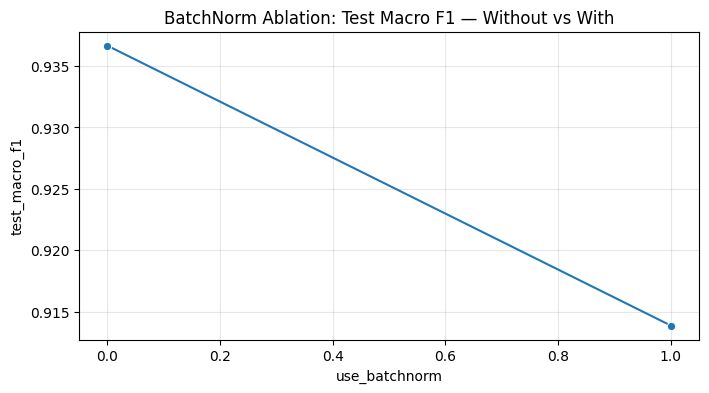

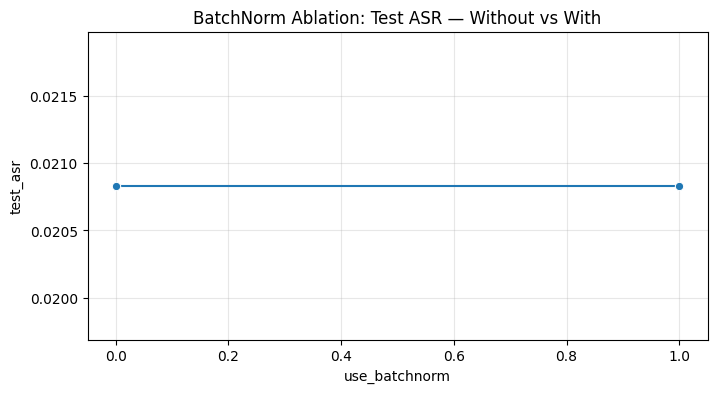

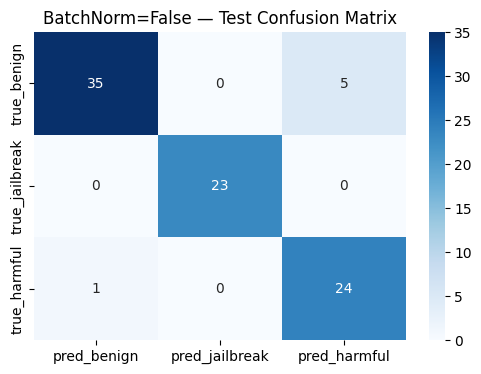

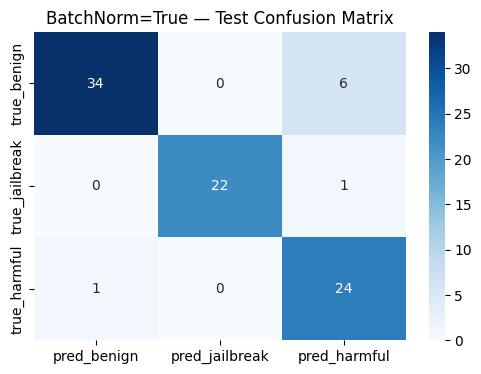

In [14]:
plot_metric(
    batchnorm_df,
    group_name="batchnorm",
    x_col="use_batchnorm",
    y_col="test_macro_f1",
    title="BatchNorm Ablation: Test Macro F1 — Without vs With"
)

plot_metric(
    batchnorm_df,
    group_name="batchnorm",
    x_col="use_batchnorm",
    y_col="test_asr",
    title="BatchNorm Ablation: Test ASR — Without vs With"
)

for r in batchnorm_results:
    show_confusion_matrix(
        r["test_eval"]["confusion_matrix"],
        f"BatchNorm={r['config'].use_batchnorm} — Test Confusion Matrix"
    )


### Interpretation prompt

After running the cells above, comment on:

- whether BatchNorm improved or hurt macro F1
- whether it changed ASR / harmful-allow-rate
- whether normalizing the [CLS] embedding helped stabilize training


# Combine all results into one table

This section merges the baseline, weight decay, noise injection, and batch normalization results into one summary table.


In [17]:
# Collect whichever experiment results are available in the current session
_frames = []

if "baseline_row" in globals():
    _frames.append(pd.DataFrame([baseline_row]))
else:
    print("Warning: baseline_row not found — skipping baseline.")

if "weight_decay_df" in globals():
    _frames.append(weight_decay_df)
else:
    print("Warning: weight_decay_df not found — skipping weight decay results.")

if "noise_df" in globals():
    _frames.append(noise_df)
else:
    print("Warning: noise_df not found — skipping noise injection results.")

if "batchnorm_df" in globals():
    _frames.append(batchnorm_df)
else:
    print("Warning: batchnorm_df not found — skipping batchnorm results.")

if not _frames:
    raise RuntimeError("No experiment results found. Run at least one experiment cell first.")

all_results_df = pd.concat(_frames, ignore_index=True)

all_results_df = all_results_df.sort_values(
    by=["experiment_group", "test_macro_f1"],
    ascending=[True, False]
).reset_index(drop=True)

display(all_results_df)
all_results_path = os.path.join(OUTPUT_DIR, "all_ablation_results.csv")
all_results_df.to_csv(all_results_path, index=False)
print("Saved:", all_results_path)


,experiment_group,setting_name,weight_decay,noise_std,dropout_p,use_batchnorm,val_accuracy,val_macro_f1,val_weighted_f1,val_asr,val_attack_detection_rate,val_harmful_allow_rate,test_accuracy,test_macro_f1,test_weighted_f1,test_asr,test_attack_detection_rate,test_harmful_allow_rate
0,batchnorm,batchnorm=False,0.0,0.0,0.0,False,0.965909,0.963695,0.965830,0.020833,0.979167,0.0,0.931818,0.936647,0.932549,0.020833,0.979167,0.04
1,batchnorm,batchnorm=True,0.0,0.0,0.0,True,0.977273,0.975553,0.977512,0.000000,1.000000,0.0,0.909091,0.913862,0.911183,0.020833,0.979167,0.04


Saved: ./phase3_ablation_outputs_small\all_ablation_results.csv


## Best setting from each factor

We select the best run inside each factor using **test macro F1** as the main criterion.
